# Task 5: Pivot Translation Portuguese → English → Swedish

This notebook implements pivot translation from Portuguese to Swedish using English as the bridge language.

Pipeline:

```text
Portuguese sentence
        ↓
Model 1: Portuguese → English
        ↓
Pivot English sentence
        ↓
Model 2: English → Swedish
        ↓
Swedish sentence
```

Expected corpus folders:

```text
pt-en/
├── europarl-v7.pt-en.pt
└── europarl-v7.pt-en.en

sv-en/
├── europarl-v7.sv-en.en
└── europarl-v7.sv-en.sv
```

The code also supports your existing project layout:

```text
machine_learning/pt-en/
machine_learning/sv-en/
```

## 1. Imports

In [1]:
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, asdict
from typing import List, Tuple
import random
import math
import time

import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

## 2. Configuration

In [2]:
try:
    PROJECT_DIR = Path(__file__).resolve().parent
except NameError:
    PROJECT_DIR = Path.cwd()

# If your folders are under machine_learning/, this will use them.
# Otherwise it falls back to folders directly under PROJECT_DIR.
ML_DIR = PROJECT_DIR / "machine_learning"

if (ML_DIR / "pt-en").exists():
    PT_EN_DIR = ML_DIR / "pt-en"
else:
    PT_EN_DIR = PROJECT_DIR / "pt-en"

if (ML_DIR / "sv-en").exists():
    SV_EN_DIR = ML_DIR / "sv-en"
else:
    SV_EN_DIR = PROJECT_DIR / "sv-en"

PT_PATH = PT_EN_DIR / "europarl-v7.pt-en.pt"
PT_EN_PATH = PT_EN_DIR / "europarl-v7.pt-en.en"

SV_EN_PATH = SV_EN_DIR / "europarl-v7.sv-en.en"
SV_PATH = SV_EN_DIR / "europarl-v7.sv-en.sv"

OUTPUT_DIR = PROJECT_DIR / "outputs_task5_pivot"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

# Use a subset first. Increase or set to None for a larger final run.
MAX_PAIRS_PT_EN = 30000
MAX_PAIRS_EN_SV = 30000

MAX_LEN = 50
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2

BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
CLIP = 1.0
TEACHER_FORCING_RATIO = 0.5

EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.3

PAD = "<pad>"
UNK = "<unk>"
SOS = "<sos>"
EOS = "<eos>"

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Project directory:", PROJECT_DIR)
print("PT-EN dir:", PT_EN_DIR)
print("SV-EN dir:", SV_EN_DIR)
print("PT file:", PT_PATH, PT_PATH.exists())
print("PT-EN English file:", PT_EN_PATH, PT_EN_PATH.exists())
print("SV-EN English file:", SV_EN_PATH, SV_EN_PATH.exists())
print("SV file:", SV_PATH, SV_PATH.exists())
print("Output directory:", OUTPUT_DIR)
print("Device:", DEVICE)

Project directory: /Users/baturu/Documents/git/NLP/machine_translation
PT-EN dir: /Users/baturu/Documents/git/NLP/machine_translation/pt-en
SV-EN dir: /Users/baturu/Documents/git/NLP/machine_translation/sv-en
PT file: /Users/baturu/Documents/git/NLP/machine_translation/pt-en/europarl-v7.pt-en.pt True
PT-EN English file: /Users/baturu/Documents/git/NLP/machine_translation/pt-en/europarl-v7.pt-en.en True
SV-EN English file: /Users/baturu/Documents/git/NLP/machine_translation/sv-en/europarl-v7.sv-en.en True
SV file: /Users/baturu/Documents/git/NLP/machine_translation/sv-en/europarl-v7.sv-en.sv True
Output directory: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task5_pivot
Device: mps


## 3. Load and preprocess corpora

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def read_lines(path: Path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return [line.rstrip("\n") for line in f]
    except UnicodeDecodeError:
        with open(path, "r", encoding="latin-1") as f:
            return [line.rstrip("\n") for line in f]

def is_empty(line: str) -> bool:
    return line.strip() == ""

def is_xml(line: str) -> bool:
    return line.strip().startswith("<")

def preprocess_pair(src: str, trg: str):
    return src.strip().lower(), trg.strip().lower()

def load_clean_parallel(src_path: Path, trg_path: Path, max_pairs=None):
    src_lines = read_lines(src_path)
    trg_lines = read_lines(trg_path)
    assert len(src_lines) == len(trg_lines), "Parallel files have different numbers of lines."

    pairs = []
    seen = set()

    for src, trg in zip(src_lines, trg_lines):
        if is_empty(src) or is_empty(trg):
            continue
        if is_xml(src) or is_xml(trg):
            continue

        src, trg = preprocess_pair(src, trg)

        if len(src.split()) > MAX_LEN or len(trg.split()) > MAX_LEN:
            continue

        pair = (src, trg)
        if pair in seen:
            continue

        seen.add(pair)
        pairs.append(pair)

    if max_pairs is not None:
        pairs = pairs[:max_pairs]

    return pairs

set_seed(RANDOM_SEED)

# Model 1 data: Portuguese → English
pt_en_pairs = load_clean_parallel(PT_PATH, PT_EN_PATH, max_pairs=MAX_PAIRS_PT_EN)

# Model 2 data: English → Swedish
en_sv_pairs = load_clean_parallel(SV_EN_PATH, SV_PATH, max_pairs=MAX_PAIRS_EN_SV)

print("PT → EN clean pairs:", len(pt_en_pairs))
print("EN → SV clean pairs:", len(en_sv_pairs))

print("\nPT → EN example:")
print("PT:", pt_en_pairs[0][0])
print("EN:", pt_en_pairs[0][1])

print("\nEN → SV example:")
print("EN:", en_sv_pairs[0][0])
print("SV:", en_sv_pairs[0][1])

PT → EN clean pairs: 30000
EN → SV clean pairs: 30000

PT → EN example:
PT: reinício da sessão
EN: resumption of the session

EN → SV example:
EN: resumption of the session
SV: återupptagande av sessionen


## 4. Train / validation / test split

In [4]:
def split_pairs(pairs, test_ratio=0.20, val_ratio=0.10, seed=42):
    rng = random.Random(seed)
    pairs = pairs[:]
    rng.shuffle(pairs)

    n = len(pairs)
    n_test = int(test_ratio * n)
    n_val = int(val_ratio * n)

    test = pairs[:n_test]
    val = pairs[n_test:n_test+n_val]
    train = pairs[n_test+n_val:]

    return train, val, test

pt_en_train, pt_en_val, pt_en_test = split_pairs(pt_en_pairs, seed=RANDOM_SEED)
en_sv_train, en_sv_val, en_sv_test = split_pairs(en_sv_pairs, seed=RANDOM_SEED)

split_df = pd.DataFrame([
    {"corpus": "PT→EN", "train": len(pt_en_train), "validation": len(pt_en_val), "test": len(pt_en_test)},
    {"corpus": "EN→SV", "train": len(en_sv_train), "validation": len(en_sv_val), "test": len(en_sv_test)},
])
display(split_df)
split_df.to_csv(OUTPUT_DIR / "task5_split_statistics.csv", index=False)

,corpus,train,validation,test
0,PT→EN,21000,3000,6000
1,EN→SV,21000,3000,6000


## 5. Tokenizer and vocabulary

In [5]:
def word_tokenize(text: str):
    return text.strip().split()

class Vocab:
    def __init__(self, texts, tokenizer=word_tokenize, max_size=None, min_freq=1):
        self.tokenizer = tokenizer
        self.specials = [PAD, UNK, SOS, EOS]

        counter = Counter()
        for text in texts:
            counter.update(tokenizer(text))

        tokens = []
        for tok, freq in counter.most_common():
            if freq < min_freq:
                continue
            if tok in self.specials:
                continue
            tokens.append(tok)

            if max_size is not None and len(tokens) >= max_size - len(self.specials):
                break

        self.itos = self.specials + tokens
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}

        self.pad_idx = self.stoi[PAD]
        self.unk_idx = self.stoi[UNK]
        self.sos_idx = self.stoi[SOS]
        self.eos_idx = self.stoi[EOS]

    def __len__(self):
        return len(self.itos)

    def encode(self, text, add_sos_eos=True):
        ids = [self.stoi.get(tok, self.unk_idx) for tok in self.tokenizer(text)]
        if add_sos_eos:
            ids = [self.sos_idx] + ids + [self.eos_idx]
        return ids

    def decode(self, ids, remove_specials=True):
        tokens = []
        for idx in ids:
            tok = self.itos[idx] if 0 <= idx < len(self.itos) else UNK
            if remove_specials and tok in {PAD, SOS, EOS}:
                continue
            tokens.append(tok)
        return tokens

## 6. Dataset and DataLoader

In [6]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab):
        self.examples = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        src, trg = self.examples[idx]
        src_ids = self.src_vocab.encode(src)
        trg_ids = self.trg_vocab.encode(trg)
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(trg_ids, dtype=torch.long)

def make_collate_fn(src_pad_idx, trg_pad_idx):
    def collate_fn(batch):
        src_batch, trg_batch = zip(*batch)

        max_src_len = max(len(x) for x in src_batch)
        max_trg_len = max(len(x) for x in trg_batch)

        padded_src = torch.full((len(batch), max_src_len), src_pad_idx, dtype=torch.long)
        padded_trg = torch.full((len(batch), max_trg_len), trg_pad_idx, dtype=torch.long)

        for i, (src, trg) in enumerate(zip(src_batch, trg_batch)):
            padded_src[i, :len(src)] = src
            padded_trg[i, :len(trg)] = trg

        return padded_src, padded_trg
    return collate_fn

def build_vocab_and_loaders(train_pairs, val_pairs, test_pairs):
    src_vocab = Vocab(
        [src for src, _ in train_pairs],
        max_size=MAX_VOCAB_SIZE,
        min_freq=MIN_FREQ
    )

    trg_vocab = Vocab(
        [trg for _, trg in train_pairs],
        max_size=MAX_VOCAB_SIZE,
        min_freq=MIN_FREQ
    )

    train_data = TranslationDataset(train_pairs, src_vocab, trg_vocab)
    val_data = TranslationDataset(val_pairs, src_vocab, trg_vocab)
    test_data = TranslationDataset(test_pairs, src_vocab, trg_vocab)

    collate_fn = make_collate_fn(src_vocab.pad_idx, trg_vocab.pad_idx)

    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    return src_vocab, trg_vocab, train_data, val_data, test_data, train_loader, val_loader

## 7. RNN encoder-decoder model

In [7]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.rnn(embedded)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, dropout, pad_idx):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)

        hidden, cell = self.encoder(src)
        input_token = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell)
            outputs[:, t, :] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = trg[:, t] if teacher_force else top1

        return outputs

def create_model(src_vocab, trg_vocab):
    encoder = Encoder(
        input_dim=len(src_vocab),
        emb_dim=EMB_DIM,
        hid_dim=HID_DIM,
        dropout=DROPOUT,
        pad_idx=src_vocab.pad_idx
    )

    decoder = Decoder(
        output_dim=len(trg_vocab),
        emb_dim=EMB_DIM,
        hid_dim=HID_DIM,
        dropout=DROPOUT,
        pad_idx=trg_vocab.pad_idx
    )

    return Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

## 8. Training and translation utilities

In [8]:
def train_epoch(model, dataloader, optimizer, criterion, clip, teacher_forcing_ratio):
    model.train()
    epoch_loss = 0

    for src, trg in dataloader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)

        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / max(1, len(dataloader))

@torch.no_grad()
def evaluate_loss(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0

    for src, trg in dataloader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        output = model(src, trg, teacher_forcing_ratio=0.0)

        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        epoch_loss += loss.item()

    return epoch_loss / max(1, len(dataloader))

@torch.no_grad()
def translate_sentence(model, sentence, src_vocab, trg_vocab, max_output_len=80):
    model.eval()

    src_ids = src_vocab.encode(sentence)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)

    hidden, cell = model.encoder(src_tensor)

    input_token = torch.tensor([trg_vocab.sos_idx], dtype=torch.long).to(DEVICE)
    output_ids = []

    for _ in range(max_output_len):
        output, hidden, cell = model.decoder(input_token, hidden, cell)
        pred_id = output.argmax(1).item()

        if pred_id == trg_vocab.eos_idx:
            break

        output_ids.append(pred_id)
        input_token = torch.tensor([pred_id], dtype=torch.long).to(DEVICE)

    return trg_vocab.decode(output_ids)

## 9. Metrics

In [9]:
def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def corpus_bleu(references, hypotheses, max_n=4):
    clipped_counts = [0] * max_n
    total_counts = [0] * max_n
    ref_len = 0
    hyp_len = 0

    for ref, hyp in zip(references, hypotheses):
        ref_len += len(ref)
        hyp_len += len(hyp)

        for n in range(1, max_n + 1):
            ref_counts = Counter(ngrams(ref, n))
            hyp_counts = Counter(ngrams(hyp, n))

            total_counts[n-1] += sum(hyp_counts.values())

            for gram, count in hyp_counts.items():
                clipped_counts[n-1] += min(count, ref_counts.get(gram, 0))

    precisions = [(c + 1) / (t + 1) for c, t in zip(clipped_counts, total_counts)]
    log_precision = sum(math.log(p) for p in precisions) / max_n

    if hyp_len == 0:
        return 0.0

    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(1, hyp_len))
    return bp * math.exp(log_precision) * 100

def char_ngrams(text, n):
    return [text[i:i+n] for i in range(len(text)-n+1)]

def sentence_chrf(reference, hypothesis, max_n=6, beta=2.0):
    scores = []

    for n in range(1, max_n + 1):
        ref_counts = Counter(char_ngrams(reference, n))
        hyp_counts = Counter(char_ngrams(hypothesis, n))

        overlap = sum(min(count, ref_counts.get(g, 0)) for g, count in hyp_counts.items())

        hyp_total = max(1, sum(hyp_counts.values()))
        ref_total = max(1, sum(ref_counts.values()))

        precision = overlap / hyp_total
        recall = overlap / ref_total

        if precision == 0 and recall == 0:
            f_score = 0.0
        else:
            f_score = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)

        scores.append(f_score)

    return sum(scores) / len(scores) * 100

def corpus_chrf(reference_texts, hypothesis_texts):
    return sum(sentence_chrf(r, h) for r, h in zip(reference_texts, hypothesis_texts)) / max(1, len(reference_texts))

@torch.no_grad()
def evaluate_model_translation(model, test_examples, src_vocab, trg_vocab, max_examples=500):
    eval_examples = test_examples[:max_examples]

    refs_tokens = []
    hyps_tokens = []
    refs_text = []
    hyps_text = []

    for src, ref in eval_examples:
        hyp_tokens = translate_sentence(model, src, src_vocab, trg_vocab, max_output_len=80)
        hyp = " ".join(hyp_tokens)

        refs_tokens.append(word_tokenize(ref))
        hyps_tokens.append(hyp_tokens)

        refs_text.append(ref)
        hyps_text.append(hyp)

    bleu = corpus_bleu(refs_tokens, hyps_tokens)
    chrf = corpus_chrf(refs_text, hyps_text)

    return bleu, chrf

## 10. General training function

In [10]:
@dataclass
class ModelBundle:
    name: str
    model: object
    src_vocab: object
    trg_vocab: object
    train_data: object
    val_data: object
    test_data: object
    history_df: object
    result: dict

def train_translation_model(name, train_pairs, val_pairs, test_pairs):
    print("\n" + "=" * 90)
    print("Training:", name)
    print("=" * 90)

    set_seed(RANDOM_SEED)

    src_vocab, trg_vocab, train_data, val_data, test_data, train_loader, val_loader = build_vocab_and_loaders(
        train_pairs, val_pairs, test_pairs
    )

    print("Source vocab size:", len(src_vocab))
    print("Target vocab size:", len(trg_vocab))
    print("Train examples:", len(train_data))
    print("Validation examples:", len(val_data))
    print("Test examples:", len(test_data))

    model = create_model(src_vocab, trg_vocab)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab.pad_idx)

    best_val_loss = float("inf")
    best_path = OUTPUT_DIR / f"{name}_best.pt"
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        start = time.time()

        train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP, TEACHER_FORCING_RATIO)
        val_loss = evaluate_loss(model, val_loader, criterion)

        elapsed = time.time() - start

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_ppl": math.exp(min(train_loss, 20)),
            "val_ppl": math.exp(min(val_loss, 20)),
            "time_sec": elapsed
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} | val loss {val_loss:.4f} | "
            f"train ppl {row['train_ppl']:.2f} | val ppl {row['val_ppl']:.2f} | "
            f"time {elapsed:.1f}s"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)
            print("Saved best model:", best_path)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    bleu, chrf = evaluate_model_translation(
        model,
        test_data.examples,
        src_vocab,
        trg_vocab,
        max_examples=500
    )

    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / f"{name}_history.csv", index=False)

    result = {
        "name": name,
        "best_val_loss": best_val_loss,
        "test_bleu": bleu,
        "test_chrf": chrf,
        "src_vocab_size": len(src_vocab),
        "trg_vocab_size": len(trg_vocab),
        "train_examples": len(train_data),
        "val_examples": len(val_data),
        "test_examples": len(test_data),
        "best_model_path": str(best_path)
    }

    print("Test BLEU:", round(bleu, 2))
    print("Test chrF:", round(chrf, 2))

    return ModelBundle(
        name=name,
        model=model,
        src_vocab=src_vocab,
        trg_vocab=trg_vocab,
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        history_df=history_df,
        result=result
    )

## 11. Train Model 1: Portuguese → English

In [11]:
pt_to_en = train_translation_model(
    name="pt_to_en",
    train_pairs=pt_en_train,
    val_pairs=pt_en_val,
    test_pairs=pt_en_test
)


Training: pt_to_en
Source vocab size: 17397
Target vocab size: 13372
Train examples: 21000
Validation examples: 3000
Test examples: 6000
Epoch 01 | train loss 6.3936 | val loss 6.3195 | train ppl 598.02 | val ppl 555.27 | time 293.4s
Saved best model: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task5_pivot/pt_to_en_best.pt
Epoch 02 | train loss 5.9896 | val loss 6.4011 | train ppl 399.25 | val ppl 602.51 | time 292.3s
Epoch 03 | train loss 5.8065 | val loss 6.2536 | train ppl 332.47 | val ppl 519.86 | time 282.1s
Saved best model: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task5_pivot/pt_to_en_best.pt
Epoch 04 | train loss 5.6527 | val loss 6.1922 | train ppl 285.06 | val ppl 488.92 | time 262.1s
Saved best model: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task5_pivot/pt_to_en_best.pt
Epoch 05 | train loss 5.5237 | val loss 6.1169 | train ppl 250.55 | val ppl 453.45 | time 257.7s
Saved best model: /Users/baturu/Documents/git/NLP/machin

## 12. Train Model 2: English → Swedish

In [12]:
en_to_sv = train_translation_model(
    name="en_to_sv",
    train_pairs=en_sv_train,
    val_pairs=en_sv_val,
    test_pairs=en_sv_test
)


Training: en_to_sv
Source vocab size: 13496
Target vocab size: 16685
Train examples: 21000
Validation examples: 3000
Test examples: 6000
Epoch 01 | train loss 6.5855 | val loss 6.2734 | train ppl 724.53 | val ppl 530.28 | time 303.2s
Saved best model: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task5_pivot/en_to_sv_best.pt
Epoch 02 | train loss 6.1599 | val loss 6.2371 | train ppl 473.38 | val ppl 511.39 | time 330.9s
Saved best model: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task5_pivot/en_to_sv_best.pt
Epoch 03 | train loss 5.9686 | val loss 6.2087 | train ppl 390.94 | val ppl 497.04 | time 306.9s
Saved best model: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task5_pivot/en_to_sv_best.pt
Epoch 04 | train loss 5.8408 | val loss 6.2089 | train ppl 344.06 | val ppl 497.13 | time 301.2s
Epoch 05 | train loss 5.7255 | val loss 6.1638 | train ppl 306.58 | val ppl 475.25 | time 20120.5s
Saved best model: /Users/baturu/Documents/git/NLP/mach

## 13. Plot training curves

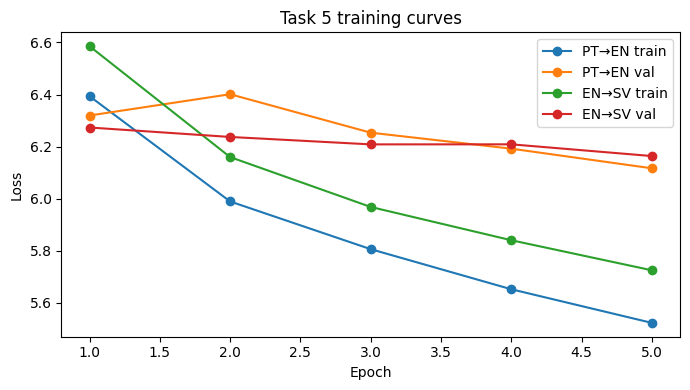

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(pt_to_en.history_df["epoch"], pt_to_en.history_df["train_loss"], marker="o", label="PT→EN train")
plt.plot(pt_to_en.history_df["epoch"], pt_to_en.history_df["val_loss"], marker="o", label="PT→EN val")
plt.plot(en_to_sv.history_df["epoch"], en_to_sv.history_df["train_loss"], marker="o", label="EN→SV train")
plt.plot(en_to_sv.history_df["epoch"], en_to_sv.history_df["val_loss"], marker="o", label="EN→SV val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 5 training curves")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task5_training_curves.png", dpi=200)
plt.show()

## 14. Pivot translation function

In [15]:
@torch.no_grad()
def pivot_translate_pt_to_sv(pt_sentence: str):
    en_tokens = translate_sentence(
        pt_to_en.model,
        pt_sentence.lower().strip(),
        pt_to_en.src_vocab,
        pt_to_en.trg_vocab,
        max_output_len=80
    )

    pivot_en_sentence = " ".join(en_tokens)

    sv_tokens = translate_sentence(
        en_to_sv.model,
        pivot_en_sentence,
        en_to_sv.src_vocab,
        en_to_sv.trg_vocab,
        max_output_len=80
    )

    sv_sentence = " ".join(sv_tokens)

    return pivot_en_sentence, sv_sentence

## 15. Test pivot translation on Portuguese examples

In [16]:
for i in range(5):
    pt_sentence, en_reference = pt_to_en.test_data.examples[i]
    pivot_en, final_sv = pivot_translate_pt_to_sv(pt_sentence)

    print(f"Example {i+1}")
    print("PT input:", pt_sentence)
    print("Reference EN:", en_reference)
    print("Predicted pivot EN:", pivot_en)
    print("Final SV:", final_sv)
    print("-" * 100)

Example 1
PT input: mas noutros países, com outras situações, as posições podem ser diferentes.
Reference EN: but other countries, in other situations, may have alternative analyses.
Predicted pivot EN: we are not the the the the the the
Final SV: det är <unk>
----------------------------------------------------------------------------------------------------
Example 2
PT input: não é lícito que, invocando, alegadamente, o princípio da solidariedade, um estado-membro possa dizer que vai tudo para um único grupo.
Reference EN: it should not be the case that one member state, under the pretext of calling on the subsidiarity principle, can decide that all funding should go to one group.
Predicted pivot EN: we is not that the is not the the the the the the the the the the the the
Final SV: vi har inte att att <unk> <unk> att <unk> <unk> att <unk> <unk>
----------------------------------------------------------------------------------------------------
Example 3
PT input: mas, aos autores d

## 16. Quantitative proxy evaluation

True PT→SV references are not available in the provided data. Therefore, we report the performance of each component model separately and provide qualitative pivot examples.

In [17]:
component_results_df = pd.DataFrame([
    pt_to_en.result,
    en_to_sv.result
])

display(component_results_df[[
    "name", "best_val_loss", "test_bleu", "test_chrf",
    "src_vocab_size", "trg_vocab_size", "train_examples", "test_examples"
]])

component_results_df.to_csv(OUTPUT_DIR / "task5_component_model_results.csv", index=False)
print("Saved:", OUTPUT_DIR / "task5_component_model_results.csv")

,name,best_val_loss,test_bleu,test_chrf,src_vocab_size,trg_vocab_size,train_examples,test_examples
0,pt_to_en,6.116883,1.017960,13.849842,17397,13372,21000,6000
1,en_to_sv,6.163842,0.349288,11.204958,13496,16685,21000,6000


Saved: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task5_pivot/task5_component_model_results.csv


## 17. Save pivot predictions

In [18]:
pivot_predictions_path = OUTPUT_DIR / "pivot_pt_to_sv_sample_predictions.txt"

with open(pivot_predictions_path, "w", encoding="utf-8") as f:
    for i in range(min(50, len(pt_to_en.test_data.examples))):
        pt_sentence, en_reference = pt_to_en.test_data.examples[i]
        pivot_en, final_sv = pivot_translate_pt_to_sv(pt_sentence)

        f.write(f"Example {i+1}\n")
        f.write(f"PT input: {pt_sentence}\n")
        f.write(f"Reference EN: {en_reference}\n")
        f.write(f"Predicted pivot EN: {pivot_en}\n")
        f.write(f"Final SV: {final_sv}\n")
        f.write("-" * 100 + "\n")

print("Saved:", pivot_predictions_path)

Saved: /Users/baturu/Documents/git/NLP/machine_translation/outputs_task5_pivot/pivot_pt_to_sv_sample_predictions.txt


## 18. Optional: translate your own Portuguese sentence

In [19]:
my_pt_sentence = "senhor presidente, gostaria de agradecer à comissão pelo seu trabalho."

pivot_en, final_sv = pivot_translate_pt_to_sv(my_pt_sentence)

print("PT:", my_pt_sentence)
print("Pivot EN:", pivot_en)
print("Final SV:", final_sv)

PT: senhor presidente, gostaria de agradecer à comissão pelo seu trabalho.
Pivot EN: mr president, commissioner, ladies and gentlemen, i would like to thank the
Final SV: jag vill inte att att att att <unk>


## 19. Report text template

You can adapt this in the report:

> For the pivot translation task, we translated Portuguese to Swedish using English as an intermediate language. Since no direct Portuguese-Swedish parallel corpus was provided, we trained two separate neural machine translation models. The first model was trained on the Portuguese-English Europarl corpus in the Portuguese-to-English direction. The second model was trained on the Swedish-English Europarl corpus in the English-to-Swedish direction. During inference, a Portuguese sentence is first translated into English, and the generated English sentence is then translated into Swedish.

> We evaluated the two component models separately using BLEU and chrF. A direct quantitative evaluation of Portuguese-to-Swedish pivot output is not possible without Portuguese-Swedish reference translations. Therefore, we report the component-level scores and provide qualitative examples of the full pivot pipeline. One limitation of this approach is error propagation: mistakes made by the Portuguese-to-English model may be passed to the English-to-Swedish model and can reduce the quality of the final Swedish translation.